In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os

In [2]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [3]:
# plotting parameters
plt.rcParams.update({
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "font.size": 25
})

In [4]:
def wind_process(T, theta, mu, wind_sigma, n, tau):
    num_to_sim = int(T / tau)
    winds = torch.zeros(n, num_to_sim + 1, device = device)
    winds[:, 0] = 0.5 * torch.rand(n , device = device) - 0.25 
    for step in range(1, num_to_sim + 1):
        dW = torch.randn(n , device = device)
        winds[:, step] = winds[:, step - 1] +(mu - winds[:, step - 1]) * theta * tau + wind_sigma * torch.sqrt(tau) * dW
    # only return winds for the integer time-steps
    final_wind = winds[:, 1:][:, ::int(1 / tau)]
    # add initial wind to the front
    winds = torch.cat((winds[:, 0].view(n, 1), final_wind), dim = 1)
    return winds

In [5]:
def running_cost(x, y, A, M):
    return( 1 - 1/(1 + torch.exp(A * (1 - x**2 - y**2)))) * M

def terminal_cost(x, y, L_x):
    return torch.norm(x - L_x, dim = 1, keepdim = True)**2 + torch.norm(y, dim = 1, keepdim = True)**2

def regularising(th1, th2, p, r):
    full_th = torch.cat((th1, th2))
    nrm = torch.norm(full_th)
    return nrm**p + 1e-9 * torch.exp(nrm)

def regularising_t(theta1, theta2, p, beta):
    theta_vmap = torch.vmap(regularising, in_dims=(0, 1, None, None))
    ells_by_j = theta_vmap(theta1, theta2, p, theta1.shape[0])
    return torch.sum(ells_by_j) / (2 * beta**2)

def gen_ref_path(reference_control, p0, winds, vs, T, n):
    ref_path = torch.zeros(n, T+1, 2, device = device) # use a 3D tensor to store path information
    ref_path[:, 0, :] = p0 
    for t in range(T): 
        heading = torch.cat([torch.cos(reference_control), torch.sin(reference_control)], dim = 1)
        wind_vec = torch.cat([torch.zeros(n, device = device).view(n, 1), winds[:, t].view(n, 1)], dim = 1)
        ref_path[:, t+1, :] = ref_path[:, t] + vs * heading + wind_vec
    return ref_path

In [6]:
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.Tanh()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled

class NeuralNet_entropy(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_entropy, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer.bias.data.zero_()
        self.hidden_layer.bias.requires_grad = False
        self.sigmoid = nn.Tanh()
        self.output_layer = nn.Linear(width, output_dim)
        self.output_layer.bias.data.zero_()
        self.output_layer.bias.requires_grad = False
        self.width = width
    def forward(self, x):
        activations = self.sigmoid(self.hidden_layer(x))
        unscaled = self.output_layer(activations)
        return unscaled/self.width

In [7]:
with open("./differing_n_regs/2025-10-25_n128_sim6_of_10.pt", "rb") as f:
    data = torch.load(f, map_location = device)

In [8]:
data

{'date': '2025-10-25',
 'n': 128,
 'T': 50,
 'L_x': 20,
 'theta': 0.1,
 'mu': 0,
 'wind_sigma': 0.05,
 'tau': tensor(1, device='mps:0'),
 'A': 2,
 'M': 10,
 'beta': 100,
 'sigma': 31.622776601683793,
 'activation_function': 'tanh',
 'network_width': 500,
 'start_rate': 0.1,
 'final_rate': 1e-09,
 'num_epochs': 40000,
 'optimiser': 'AdamW',
 'scheduler': 'CosineAnnealingLR',
 'vs': 0.8,
 'training_data': tensor([[-0.2164, -0.2595, -0.2462,  ...,  0.1019,  0.1813,  0.2034],
         [-0.1721, -0.1401, -0.1532,  ...,  0.0212,  0.0042, -0.0662],
         [ 0.0155,  0.0788,  0.0885,  ..., -0.0928, -0.0216, -0.0496],
         ...,
         [-0.0321, -0.0239, -0.0470,  ..., -0.0786, -0.0306,  0.0004],
         [-0.2260, -0.2472, -0.1725,  ...,  0.0754,  0.0222,  0.1036],
         [-0.2058, -0.1850, -0.1050,  ..., -0.1172, -0.1499, -0.1908]],
        device='mps:0'),
 'entropy_model_parameters': [OrderedDict([('hidden_layer.weight',
                tensor([[ 0.5689, -0.0135, -0.1521, -0.9529],

In [9]:
# collect hyperparameters
n = data["n"]
T = data["T"]
tau = data["tau"]
L_x = data["L_x"]
theta = data["theta"]
mu = data["mu"]
wind_sigma = data["wind_sigma"]
A = data["A"]
M = data["M"]
entropy_width = data["network_width"]
beta = data["beta"]
sigma = data["sigma"]
vs = data["vs"]
training_winds = data["training_data"]

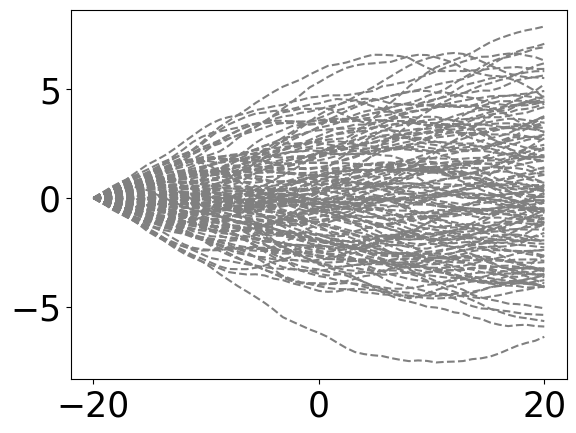

In [10]:
# generate reference trajectories
ref_ctrl = torch.zeros(n, 1, device = device)
initial_points = torch.zeros(n, 2, device = device) - torch.tensor([20, 0], device = device)
ref_path = gen_ref_path(ref_ctrl, initial_points, training_winds, vs, T, n)

for r in range(n):
    plt.plot(ref_path[r, :, 0].cpu(), ref_path[r, :, 1].cpu(), color = "gray", linestyle = "--")

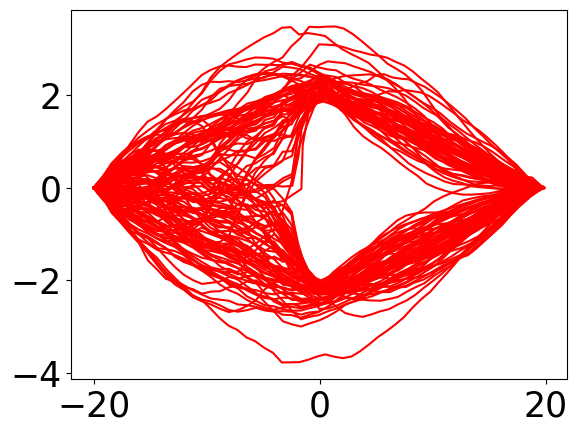

In [11]:
# generate the realised paths

# entropy-regularised
entropy_params = [params for params in data["entropy_model_parameters"]]
reg_models = [NeuralNet_entropy(4, entropy_width, 1).to(device) for _ in range(T)]
for model, state in zip(reg_models, entropy_params):
    model.load_state_dict(state)
    model.to(device)

train_paths_reg = [initial_points]

# then for entropy-regularised
for t in range(T):
    angle = reg_models[t](torch.cat([train_paths_reg[-1]/torch.tensor([20, 10], device = device),
                                     training_winds[:, t].view(n, 1),
                                     torch.ones(n, 1, device = device)], dim = 1))
    heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
    wind_vec = torch.cat([torch.zeros(n, 1, device = device), training_winds[:, t].view(n ,1)], dim = 1)
    new_p = train_paths_reg[-1] + vs * heading + wind_vec
    train_paths_reg.append(new_p)
train_paths_reg = torch.stack(train_paths_reg, dim = 1)

for pth in range(n):
    plt.plot(train_paths_reg[pth, :, 0].detach().cpu(), train_paths_reg[pth, :, 1].detach().cpu(), color = "red")

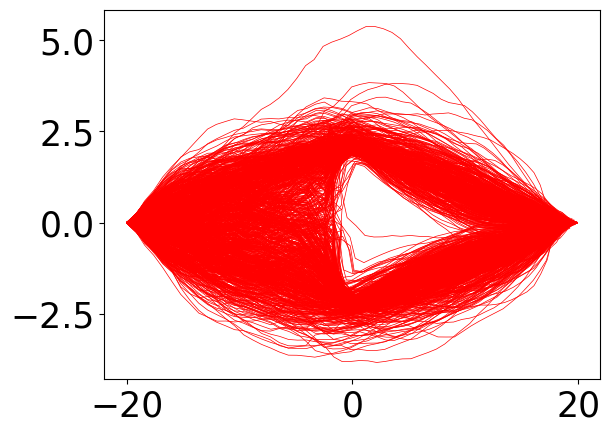

In [12]:
# generate test winds
test_size = 1000
test_winds = wind_process(T, theta, mu, wind_sigma, test_size, tau)

# generate test trajectories
test_paths_reg = [torch.zeros(test_size, 2, device = device) - torch.tensor([20, 0], device = device)]

# entropy-regularised
for t in range(T):
    angle = reg_models[t](torch.cat([test_paths_reg[-1]/torch.tensor([20, 10], device = device),
                                     test_winds[:, t].view(test_size, 1),
                                     torch.ones(test_size, 1, device = device)], dim = 1))
    heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
    wind_vec = torch.cat([torch.zeros(test_size, 1, device = device), test_winds[:, t].view(test_size, 1)], dim =1)
    new_p = test_paths_reg[-1] + vs * heading + wind_vec
    test_paths_reg.append(new_p)
test_paths_reg = torch.stack(test_paths_reg, dim = 1)

for pth in range(test_size):
    plt.plot(test_paths_reg[pth, :, 0].detach().cpu(), test_paths_reg[pth, :, 1].detach().cpu(), color = "red", linewidth = 0.5)

In [13]:
# plotting parameters
plt.rcParams.update({
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "font.size": 25
})

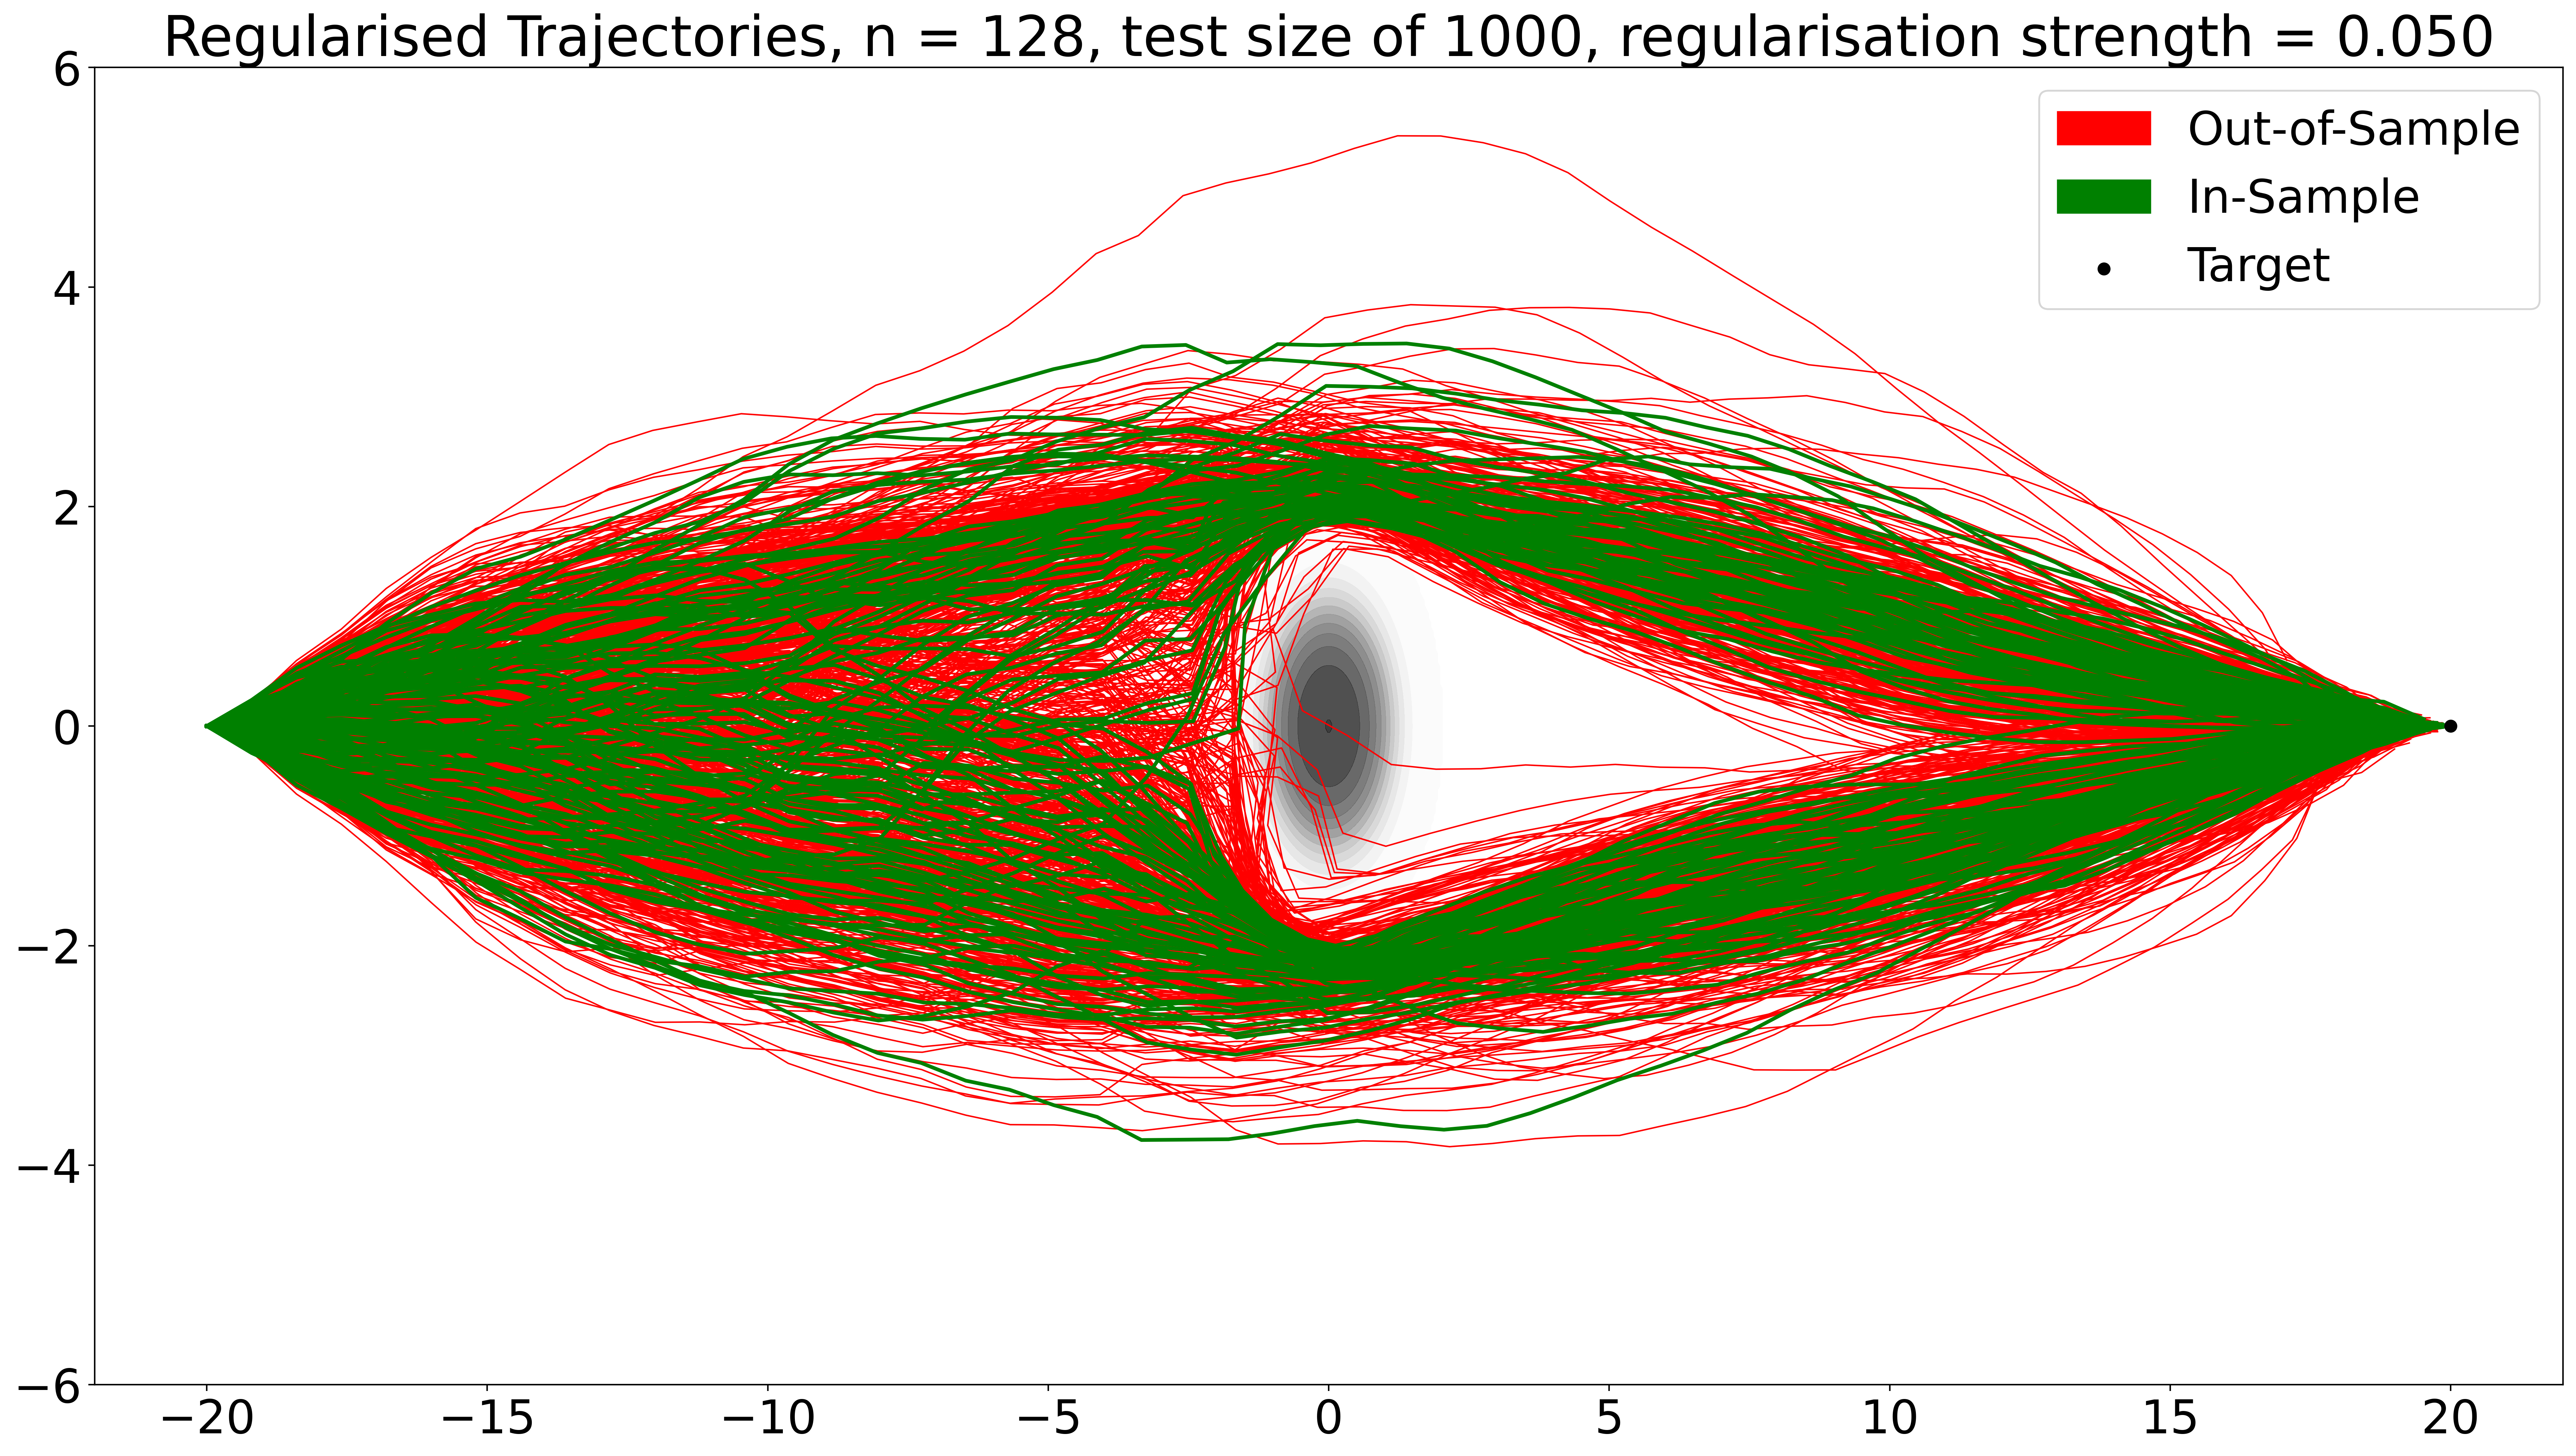

In [14]:
# entropy-regularised in-sample vs. out-of-sample
red = mpatches.Patch(color="red", label="Out-of-Sample")
green = mpatches.Patch(color="green", label="In-Sample")
fig, ax = plt.subplots(figsize=(19.2, 10.8), dpi=400,
                       constrained_layout = True)
grid_res = 300  # Resolution of the grid
x_vals = torch.linspace(-6, 6, grid_res)
y_vals = torch.linspace(-6, 6, grid_res)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
Z = running_cost(X, Y, A=2, M=10)*100
Z[Z < 1.5] = float('nan')
ax.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=10, cmap='Greys', alpha=0.8)

for pth in range(test_size):
    plt.plot(test_paths_reg[pth, :, 0].detach().cpu(), test_paths_reg[pth, :, 1].detach().cpu(),
             color = "red", linewidth = 0.8)
for pth in range(n):
    plt.plot(train_paths_reg[pth, :, 0].detach().cpu(), train_paths_reg[pth, :, 1].detach().cpu(),
             color = "green", linewidth = 2)

ax.set_title(f"Regularised Trajectories, n = {n}, test size of {test_size}, regularisation strength = {sigma**2/(2*beta**2):.3f}")
targ = ax.scatter(x=20, y=0, label="Target", color="black", zorder=1000)
ax.legend(handles=[red, green, targ])
plt.show()
plt.close()

In [15]:
training_winds.shape

torch.Size([128, 51])

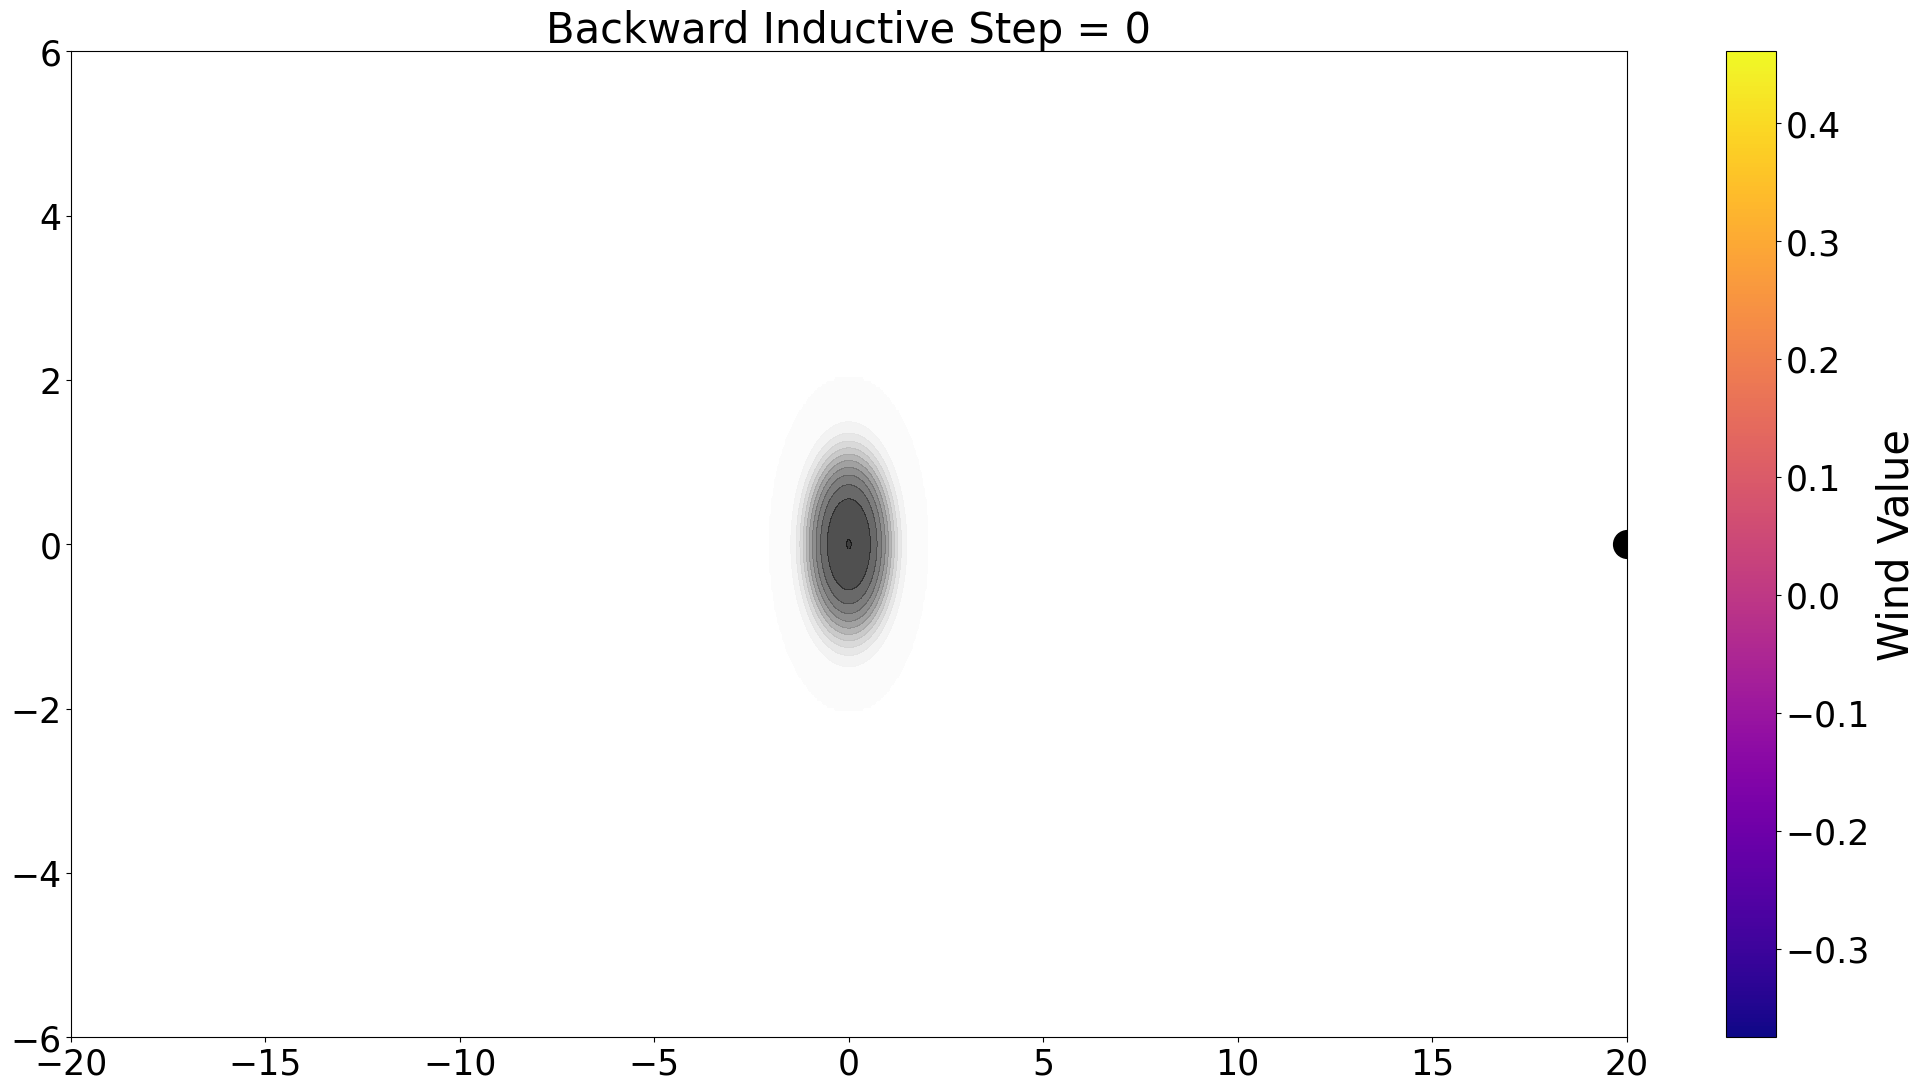

In [16]:
# entropy-regularised
ref_control = torch.zeros(n, 1, device=device)
ref_path = [initial_points.to(device)] 

for pos in range(T):
    wind_y = training_winds[:, pos].view(n, 1).to(device)
    wind_vector = torch.cat([torch.zeros_like(wind_y), wind_y], dim=1)
    heading = torch.cat([torch.cos(ref_control), torch.sin(ref_control)], dim=1)
    velocity = vs * heading +  wind_vector
    new_p = ref_path[-1] + velocity
    ref_path.append(new_p)

# Backward rollout
anim_paths = {}
wind_values = {}

anim_paths[f"{T}"] = ref_path
for t in range(T - 1, -1, -1):
    curr_path = ref_path[:t + 1]
    # curr_wind = [training_data[:, :t + 1]]
    curr_wind = [training_winds[:, i].view(n, 1) for i in range(t + 1)]

    curr_p = curr_path[-1]
    for rem in range(0, T - t):
        wind_val = training_winds[:, t + rem].view(n, 1).to(device)
        wind_vector = torch.cat([torch.zeros_like(wind_val), wind_val], dim=1)
        input_tensor = torch.cat((curr_p/torch.tensor([20, 10], device = device), 
                                  wind_val, torch.ones(n, 1, device = device)), dim=1)

        curr_control = reg_models[t + rem](input_tensor)
        heading = torch.cat([torch.cos(curr_control), torch.sin(curr_control)], dim=1)
        velocity = vs * heading + wind_vector
        curr_p = curr_p + velocity

        curr_path.append(curr_p)
        curr_wind.append(wind_val)

    anim_paths[f"{t}"] = curr_path
    wind_values[f"{t}"] = curr_wind

# Prepare data for animation
plt.rcParams['animation.embed_limit'] = 100  # in MB
frame_data = []
for key in sorted(anim_paths.keys(), key=lambda k: int(k)):
    step_list = anim_paths[key]
    wind_list = wind_values.get(key, [])
    positions = torch.stack(step_list, dim=0).detach().cpu()  # (steps, N, 2)
    wind_vals = torch.stack(wind_list, dim=0).squeeze(-1).detach().cpu() if wind_list else None  # (steps, N)
    frame_data.append((int(key), positions, wind_vals))
frame_data.reverse()

# Setup plot
L_x, L_y = 20, 6
num_paths_to_show = n
interval = 100


plt.rcParams.update({
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "font.size": 25
})
fig, ax = plt.subplots(figsize=(19.2, 10.8), constrained_layout=True)
ax.set_xlim(-L_x, L_x)
ax.set_ylim(-L_y, L_y)
ax.plot(20, 0, 'ko', markersize=20, zorder=1000)

# Obstacle contour
grid_res = 300
x_vals = torch.linspace(-6, 6, grid_res)
y_vals = torch.linspace(-6, 6, grid_res)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
Z = running_cost(X, Y, A=2, M=10) * 100
Z[Z < 1.5] = float('nan')
ax.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=10, cmap='Greys', alpha=0.8)

# Plot elements
grey_lines = [ax.plot([], [], linestyle='--', color='grey', lw=1)[0] for _ in range(num_paths_to_show)]
collections = []
# Plotting parameters

norm = plt.Normalize(training_winds.min().item(), training_winds.max().item())
cmap = plt.cm.plasma
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Wind Value")

# --- Animation functions ---
def init():
    for line in grey_lines:
        line.set_data([], [])
    for coll in collections:
        coll.remove()
    collections.clear()
    return grey_lines

def update(frame_idx):
    for coll in collections:
        coll.remove()
    collections.clear()

    epoch_idx, data, winds = frame_data[frame_idx]
    ax.set_title(f"Backward Inductive Step = {epoch_idx}")

    for i in range(num_paths_to_show):
        if i >= data.shape[1]:
            continue
        x = data[:, i, 0].numpy()
        y = data[:, i, 1].numpy()

        # Grey past
        grey_lines[i].set_data(x[:epoch_idx + 1], y[:epoch_idx + 1])

        # Color future
        if winds is not None and epoch_idx < data.shape[0] - 1:
            segments = np.stack([x[epoch_idx:], y[epoch_idx:]], axis=-1)
            points = segments[:-1]
            segs = np.stack([points, segments[1:]], axis=1)
            colors = cmap(norm(winds[epoch_idx + 1:, i].numpy()))

            lc = LineCollection(segs, colors=colors, linewidths=2)
            ax.add_collection(lc)
            collections.append(lc)

    return grey_lines + collections

ani = animation.FuncAnimation(
    fig, update, frames=len(frame_data),
    init_func=init, blit=False, interval=interval
)

# HTML(ani.to_jshtml())
ani.save("entropy_reg_backward_induction.gif",
         writer = "pillow",
         fps = int(1000/interval))

In [17]:
terminal_costs_reg_train = terminal_cost(train_paths_reg[:, -1, 0].view(n ,1),
                                         train_paths_reg[:, -1, 1].view(n, 1), L_x)
terminal_costs_reg_test = terminal_cost(test_paths_reg[:, -1, 0].view(test_size ,1),
                                        test_paths_reg[:, -1, 1].view(test_size, 1), L_x)
# convert to numpy, then take logs
terminal_costs_reg_train = np.array(terminal_costs_reg_train[:,0].detach().cpu())
terminal_costs_reg_test = np.array(terminal_costs_reg_test[:,0].detach().cpu())

/var/folders/9c/wcsxhf855z99lwfkhxwhhspm0000gn/T/ipykernel_41093/3677607540.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  terminal_costs_reg_train = np.array(terminal_costs_reg_train[:,0].detach().cpu())
/var/folders/9c/wcsxhf855z99lwfkhxwhhspm0000gn/T/ipykernel_41093/3677607540.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  terminal_costs_reg_test = np.array(terminal_costs_reg_test[:,0].detach().cpu())


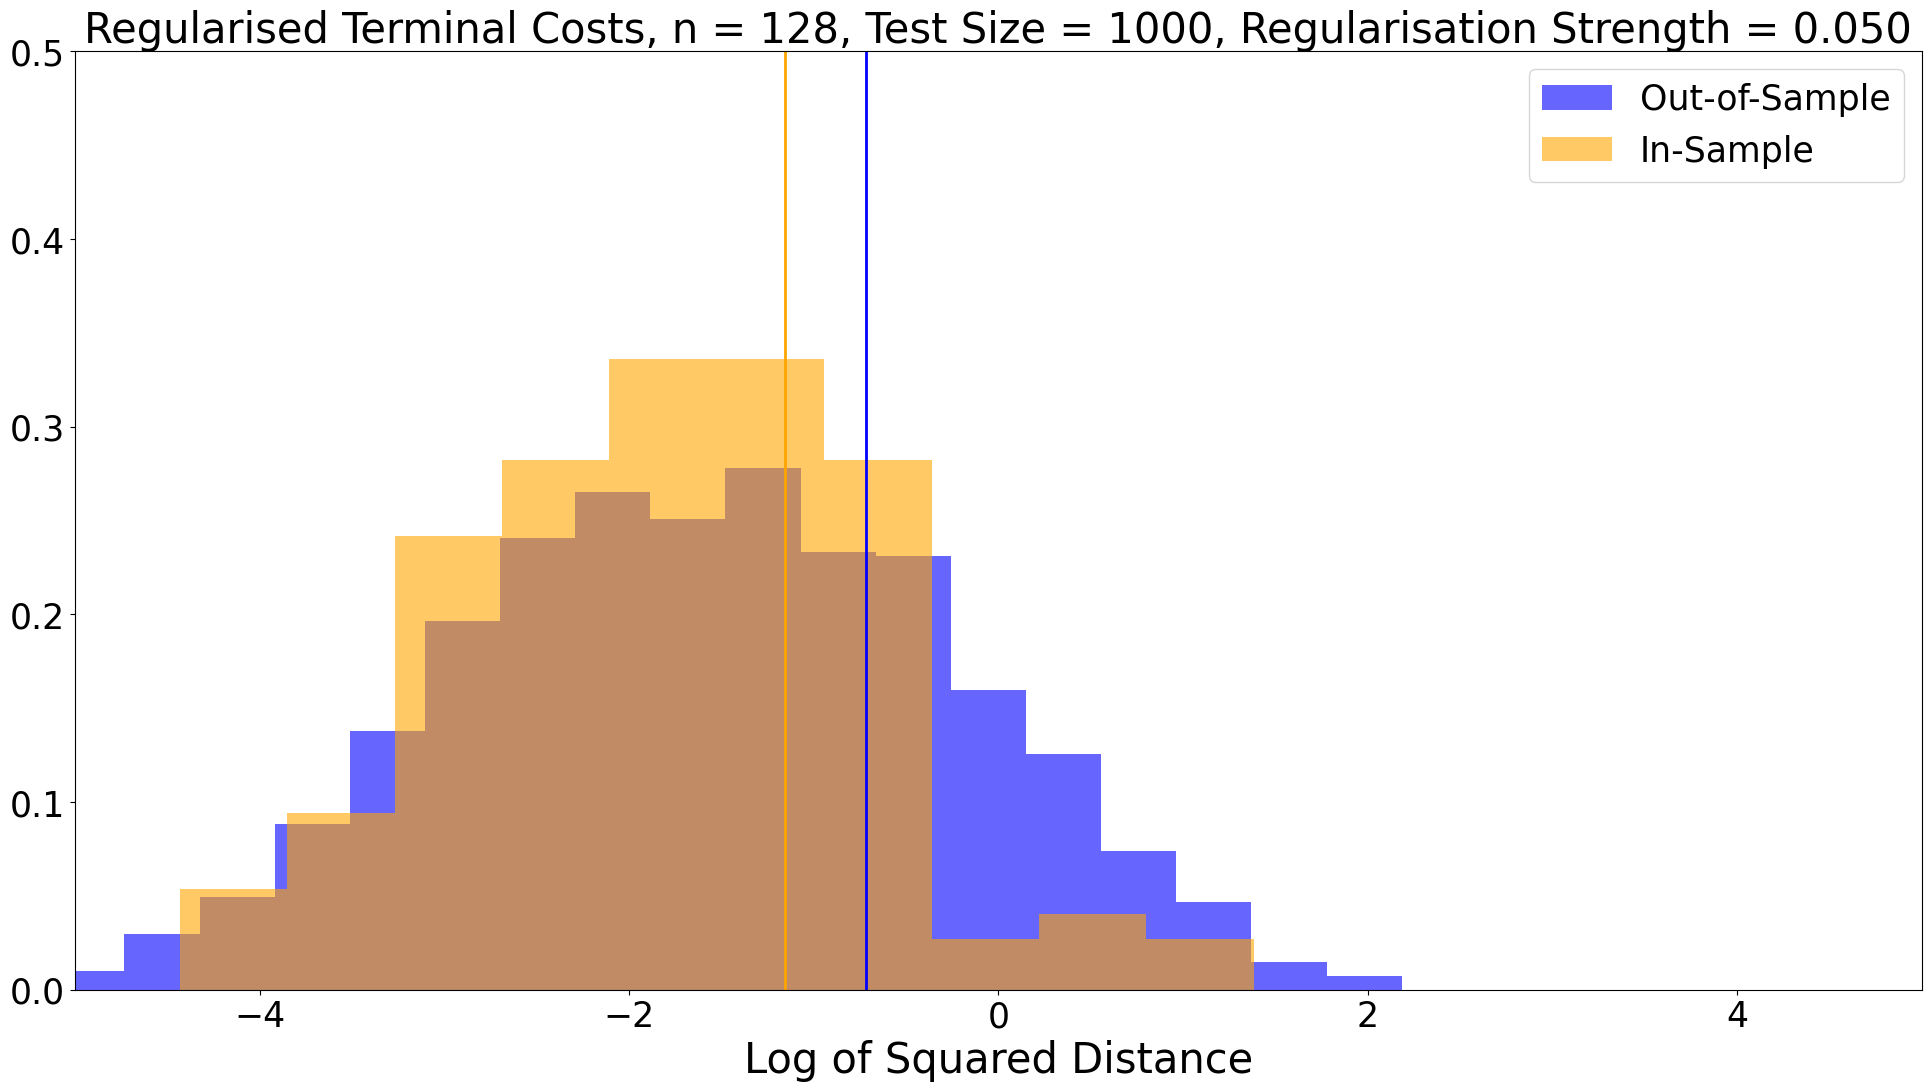

In [18]:
fig, ax = plt.subplots(figsize = (19.2, 10.8), constrained_layout = True)
ax.hist(np.log(terminal_costs_reg_test), bins = 20, density = True, alpha = 0.6, color = "blue", label = "Out-of-Sample")
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.5)
ax.hist(np.log(terminal_costs_reg_train), bins = 10, density = True, alpha = 0.6, color = "orange", label = "In-Sample")
tick_location_1 = np.log(np.mean(terminal_costs_reg_test))
ax.axvline(x=tick_location_1, color='blue', linewidth=2, linestyle = "-")
tick_location_2 = np.log(np.mean(terminal_costs_reg_train))
ax.axvline(x=tick_location_2, color='orange', linewidth=2)
ax.set_xlabel("Log of Squared Distance")
ax.set_title(f"Regularised Terminal Costs, n = {n}, Test Size = {test_size}, Regularisation Strength = {sigma**2/(2*beta**2):.3f}")
ax.legend()
plt.show()

In [19]:
# let's do the same, but with the obstacle cost included too
full_cost_train_reg = (torch.sum(running_cost(train_paths_reg[:, :, 0], train_paths_reg[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                             + terminal_cost(train_paths_reg[:, -1, 0].view(n, 1),
                                             train_paths_reg[:, -1, 1].view(n, 1), L_x).detach().cpu().numpy()[:, 0])
full_cost_test_reg = (torch.sum(running_cost(test_paths_reg[:, :, 0], test_paths_reg[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                             + terminal_cost(test_paths_reg[:, -1, 0].view(test_size, 1),
                                             test_paths_reg[:, -1, 1].view(test_size, 1), L_x).detach().cpu().numpy()[:, 0])

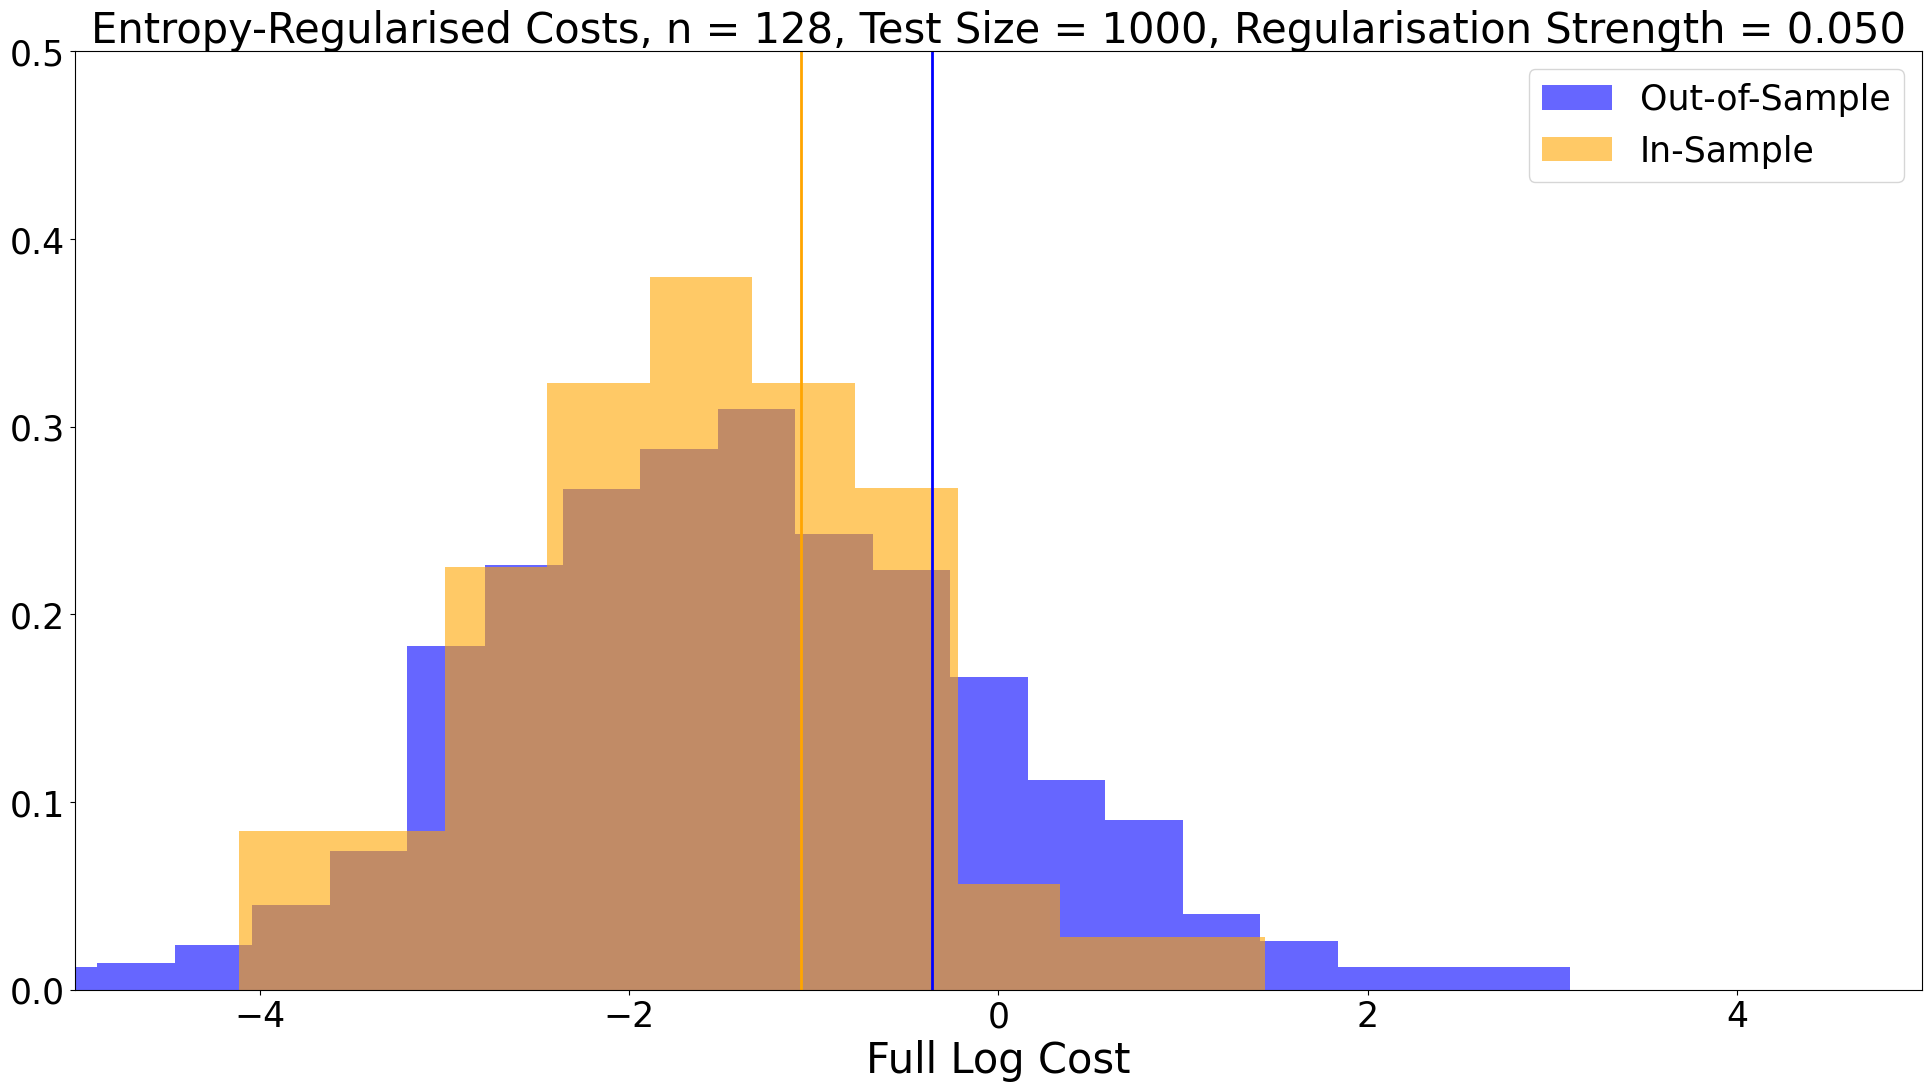

In [20]:
fig, ax = plt.subplots(figsize = (19.2, 10.8), constrained_layout = True)
ax.hist(np.log(full_cost_test_reg), bins = 20, density = True, alpha = 0.6, color = "blue", label = "Out-of-Sample")
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.5)
ax.hist(np.log(full_cost_train_reg), bins = 10, density = True, alpha = 0.6, color = "orange", label = "In-Sample")
tick_location_1 = np.log(np.mean(full_cost_test_reg))
ax.axvline(x=tick_location_1, color='blue', linewidth=2, linestyle = "-")
tick_location_2 = np.log(np.mean(full_cost_train_reg))
ax.axvline(x=tick_location_2, color='orange', linewidth=2)
ax.set_xlabel("Full Log Cost")
ax.set_title(f"Entropy-Regularised Costs, n = {n}, Test Size = {test_size}, Regularisation Strength = {sigma**2/(2*beta**2):.3f}")
ax.legend()
plt.show()

In [21]:
# now we take outputs from the ns_to_visualise folder, compute in + out of sample metrics, and draw the boxplots
full_pd = pd.DataFrame(columns = ["8", "16", "32", "64"])
test_size = 150000 # must be large enough that we have a good estimator
test_winds = wind_process(T, theta, mu, wind_sigma, test_size, tau)

def extract_n(filename):
    # Find the part after "n" and before "_"
    n_str = filename.split("n")[1].split("_")[0]
    return n_str
    
for file in os.listdir("ns_to_visualise"):
    # load file torch objects
    route = os.path.join("./ns_to_visualise", file)
    with open(route, "rb") as f:
        data = torch.load(f, map_location = device)
    # compute in-sample performance
    entropy_params = [params for params in data["entropy_model_parameters"]]
    reg_models = [NeuralNet_entropy(4, entropy_width, 1).to(device) for _ in range(T)]
    for model, state in zip(reg_models, entropy_params):
        model.load_state_dict(state)
        model.to(device)
    n = data["n"]
    training_winds = data["training_data"]
    initial_points = torch.zeros(n, 2, device = device) - torch.tensor([20, 0], device = device)
    train_paths_reg = [initial_points]
    for t in range(T):
        angle = reg_models[t](torch.cat([train_paths_reg[-1]/torch.tensor([20, 10], device = device),
                                        training_winds[:, t].view(n, 1),
                                        torch.ones(n, 1, device = device)], dim = 1))
        heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
        wind_vec = torch.cat([torch.zeros(n, 1, device = device), training_winds[:, t].view(n ,1)], dim = 1)
        new_p = train_paths_reg[-1] + vs * heading + wind_vec
        train_paths_reg.append(new_p)
    train_paths_reg = torch.stack(train_paths_reg, dim = 1)
    # now for out-of-sample
    test_paths_reg = [torch.zeros(test_size, 2, device = device) - torch.tensor([20, 0], device = device)]
    for t in range(T):
        angle = reg_models[t](torch.cat([test_paths_reg[-1]/torch.tensor([20, 10], device = device),
                                        test_winds[:, t].view(test_size, 1),
                                        torch.ones(test_size, 1, device = device)], dim = 1))
        heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
        wind_vec = torch.cat([torch.zeros(test_size, 1, device = device), test_winds[:, t].view(test_size, 1)], dim =1)
        new_p = test_paths_reg[-1] + vs * heading + wind_vec
        test_paths_reg.append(new_p)
    test_paths_reg = torch.stack(test_paths_reg, dim = 1)
    # computing losses
    full_cost_train_reg = np.mean(torch.sum(running_cost(train_paths_reg[:, :, 0], train_paths_reg[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                             + terminal_cost(train_paths_reg[:, -1, 0].view(n, 1),
                                             train_paths_reg[:, -1, 1].view(n, 1), L_x).detach().cpu().numpy()[:, 0])
    full_cost_test_reg = np.mean(torch.sum(running_cost(test_paths_reg[:, :, 0], test_paths_reg[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                                + terminal_cost(test_paths_reg[:, -1, 0].view(test_size, 1),
                                                test_paths_reg[:, -1, 1].view(test_size, 1), L_x).detach().cpu().numpy()[:, 0])
    # write to relevant entry of dataframe
    n_size = extract_n(file)
    full_pd.loc[full_pd.shape[0], n_size] = np.abs(full_cost_test_reg - full_cost_train_reg)

In [22]:
col_clean_lists = {col: full_pd[col].dropna().tolist() for col in full_pd.columns}
rect_df = pd.DataFrame({k: pd.Series(v) for k, v in col_clean_lists.items()})
rect_df

,8,16,32,64,128
0,1.150403,1.314592,0.508432,0.087538,0.286592
1,1.404951,0.687079,0.403521,0.133040,0.070723
2,2.784284,0.583396,0.307470,0.026336,0.150825
3,1.384503,1.156909,0.262181,0.704224,0.251791
4,0.854089,0.253831,0.190795,0.441601,0.105302
5,1.222235,1.275868,0.485952,0.032504,0.254237
6,1.873427,0.616652,0.541182,0.622696,0.220058
7,2.271702,0.712536,0.411952,0.305053,0.170679
8,1.208880,0.464444,0.249742,0.333312,0.338189
9,1.523212,1.207457,0.393474,0.064450,0.137570


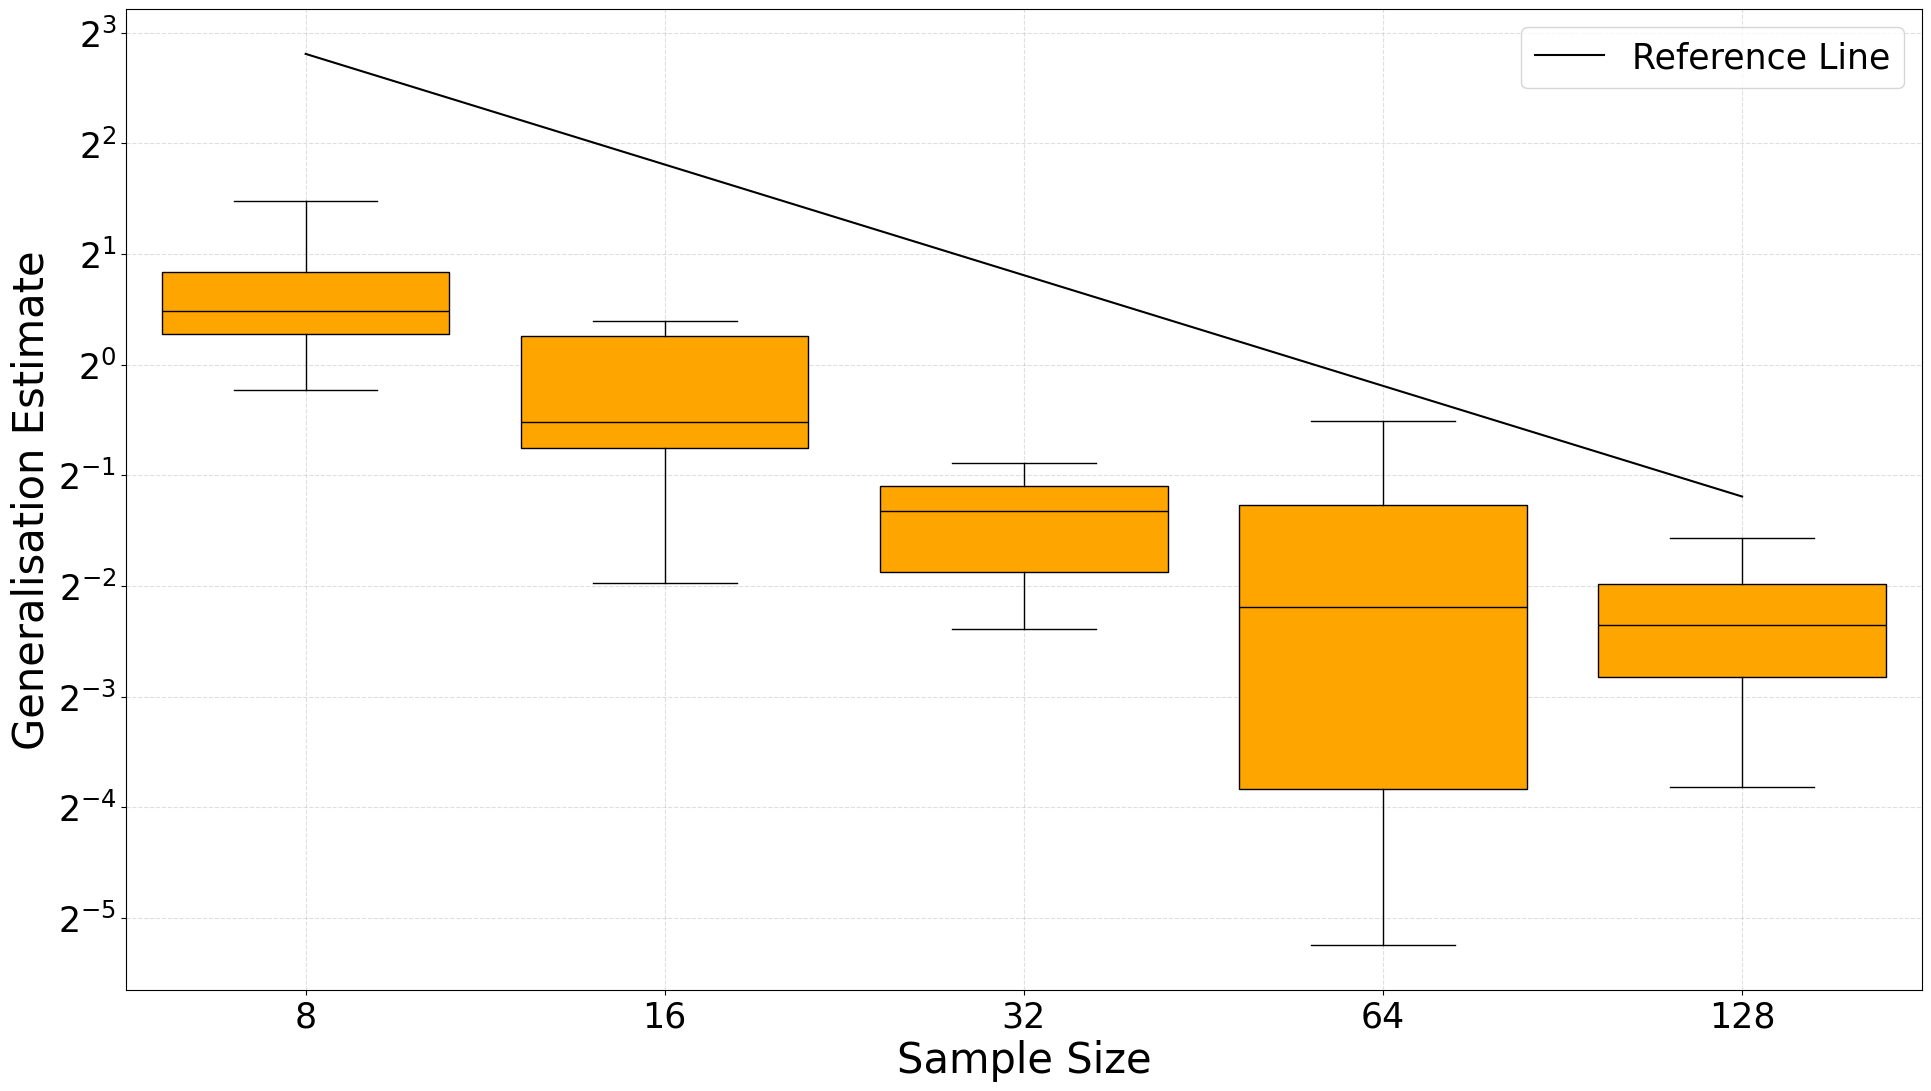

In [24]:
fig, ax = plt.subplots(figsize = (19.2, 10.8), constrained_layout = True)
rect_df.boxplot(sym = "r+",
                widths = 0.8,
                boxprops = dict(facecolor = "orange", color = "black"),
                medianprops = dict(color = "black"),
                whiskerprops = dict(color = "black"),
                patch_artist = True,
                whis=[0, 100])

plt.xticks(ticks=range(1, len(full_pd.columns) + 1),
           labels=[int(c) for c in full_pd.columns])
# Set log2 scaling for the y-axis
plt.yscale("log", base=2)   # log base 2
# Titles and labels
plt.xlabel("Sample Size")
plt.ylabel("Generalisation Estimate")
plt.grid(True, linestyle="--", alpha=0.4)
# adding reference line
xs = [1, 2, 3, 4, 5]
ys = []
for x in xs:
    ys.append(14*2**(-x))
plt.plot(xs, ys, color = "black", label = "Reference Line")
plt.legend()
plt.show()